In [ ]:
from google.colab import files
uploaded=files.upload()
print(uploaded)

Saving newcomplete.csv to newcomplete.csv
{'newcomplete.csv': b'\xef\xbb\xbfD,E,Depth,Pi,Sigma,Disp\r\n5.2,2740.3,470,200,12690,28.525\r\n5.2,2740.3,470,400,12690,28.3015\r\n5.2,2740.3,470,600,12690,28.0781\r\n5.2,2740.3,470,800,12690,27.8546\r\n5.2,2740.3,470,1000,12690,27.6311\r\n5.2,2740.3,470,1200,12690,27.4076\r\n5.2,2740.3,470,1400,12690,27.1841\r\n5.2,2740.3,470,1600,12690,26.9606\r\n5.2,2740.3,470,1800,12690,26.7371\r\n5.2,2740.3,470,2000,12690,26.5137\r\n5.2,2740.3,470,4000,12690,24.2779\r\n5.2,2740.3,470,6000,12690,22.043\r\n5.2,2740.3,470,8000,12690,19.8081\r\n5.2,2740.3,470,10000,12690,17.5733\r\n5.2,2740.3,470,12000,12690,15.3384\r\n5.2,2740.3,470,14000,12690,13.1036\r\n5.2,2740.3,470,16000,12690,10.869\r\n5.2,2000,470,200,12690,39.0834\r\n5.2,2000,470,400,12690,38.7772\r\n5.2,2000,470,600,12690,38.4707\r\n5.2,2000,470,800,12690,38.1641\r\n5.2,2000,470,1000,12690,37.8585\r\n5.2,2000,470,1200,12690,37.552\r\n5.2,2000,470,1400,12690,37.2458\r\n5.2,2000,470,1600,12690,36.9392

In [ ]:
import pandas as pd
import io
df = pd.read_csv('newcomplete.csv')

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
df['1/E'] = np.reciprocal(df['E'])
X = df[['D', '1/E', 'Depth', 'Pi', 'Sigma']]
y = df['Disp']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import RMSprop

model = Sequential([
    Dense(64, input_dim=X_train.shape[1], activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
])
# Compile with RMSprop optimizer
optimizer = RMSprop(learning_rate=0.001)  # You can try 0.0005 or 0.01 too
model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
history = model.fit(X_train, y_train, validation_split=0.1, epochs=200, batch_size=16, verbose=1)

Epoch 1/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.1585 - mae: 0.7789 - val_loss: 0.5311 - val_mae: 0.4691
Epoch 2/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.6550 - mae: 0.7064 - val_loss: 0.4926 - val_mae: 0.4847
Epoch 3/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.2735 - mae: 0.6655 - val_loss: 0.6466 - val_mae: 0.5582
Epoch 4/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.1279 - mae: 0.7377 - val_loss: 1.1203 - val_mae: 0.7671
Epoch 5/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.5744 - mae: 0.6633 - val_loss: 0.4763 - val_mae: 0.4610
Epoch 6/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.8010 - mae: 0.7254 - val_loss: 2.1982 - val_mae: 1.0156
Epoch 7/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.8203 - mae: 0.8085 - val_loss: 1.9680 - val_mae: 1.0019
Epoch 8/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.2480 - mae: 0.5979 - val_loss: 9.3974 - val_mae: 2.0953
Epoch 9/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.533

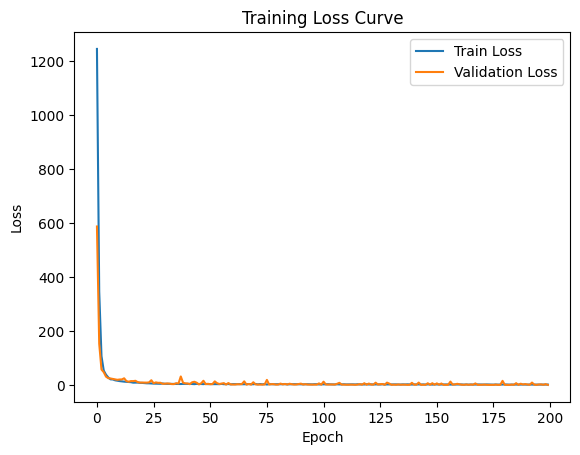

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training Loss Curve')
plt.show()

In [ ]:
loss, mae = model.evaluate(X_test, y_test)
print(f"Test MAE: {mae}")

# Predictions
y_pred = model.predict(X_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5458 - mae: 0.4998  
Test MAE: 0.5043246150016785
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


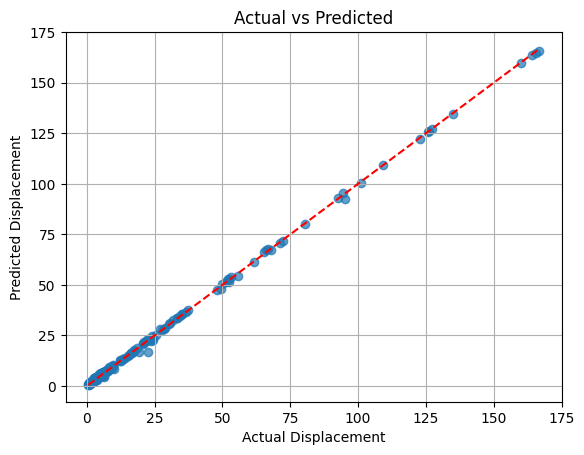

In [ ]:
import matplotlib.pyplot as plt

y_pred = model.predict(X_test).flatten()

plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel('Actual Displacement')
plt.ylabel('Predicted Displacement')
plt.title('Actual vs Predicted')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # 1:1 line
plt.grid(True)
plt.show()


In [ ]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
print(f"R² Score: {r2}")


R² Score: 0.9995048848958473


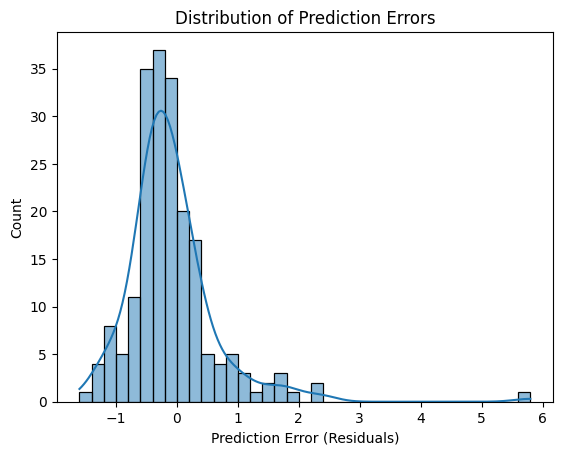

In [ ]:
import seaborn as sns

residuals = y_test - y_pred
sns.histplot(residuals, kde=True)
plt.title('Distribution of Prediction Errors')
plt.xlabel('Prediction Error (Residuals)')
plt.show()


In [ ]:
# Example: new input as a list of values
# Order of features: ['diameter', 'young_modulus', 'Depth', 'Pi', 'sigma']
D = float(input("Enter Diameter (m): "))
E = float(input("Enter Young's Modulus (MPa): "))
Depth = float(input("Enter Depth (m): "))
Pi = float(input("Enter Internal Pressure (kPa): "))  # If you're using kPa
Sigma = float(input("Enter Sigma (kpa) Ratio: "))
ABC = np.reciprocal(E)
# Combine into a single array
new_data = np.array([[D, ABC, Depth, Pi, Sigma]])

# Scale the new input using the same scaler
new_data_scaled = scaler.transform(new_data)

# Predict
predicted_Disp = model.predict(new_data_scaled)
print(f"Predicted Displacement: {predicted_Disp[0][0]:.4f}")


Enter Diameter (m): 3
Enter Young's Modulus (MPa): 3000
Enter Depth (m): 500
Enter Internal Pressure (kPa): 200
Enter Sigma (kpa) Ratio: 13500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Predicted Displacement: 14.3682


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


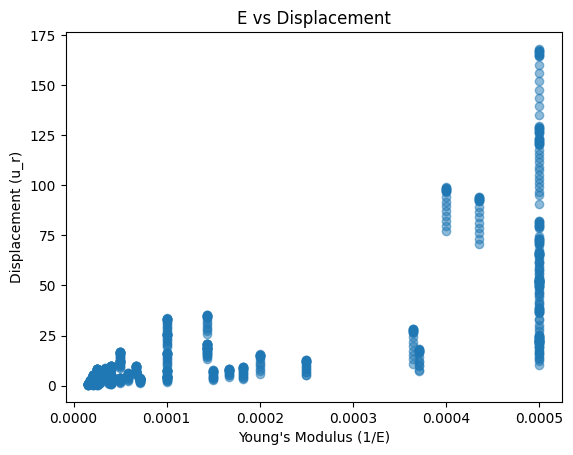

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(df['1/E'], df['Disp'], alpha=0.5)
plt.xlabel('Young\'s Modulus (1/E)')
plt.ylabel('Displacement (u_r)')
plt.title('E vs Displacement')
plt.show()

In [ ]:
model.save('Model8.keras')

In [ ]:
import joblib
joblib.dump(scaler, "scaler1.save")

['scaler1.save']